# GiBUU Data Preparation

This notebook prepares data for training the interaction and propagation models.

**Workflow:**
1. **Configuration** (always run first)
2. **ROOT → H5** (optional - skip if H5 files exist)
3. **Process H5 → Pairs** (can start here if H5 exists)
   - 3.1: Extract sequences
   - 3.2: Extract pairs
   - 3.3: Filter by changes
   - 3.4: Save to NPZ
- **Test** (verify NPZ loading; calculate statistics; plot distributions)
- **Training Integration** (examples for next steps)

**Output:**
- `npz_with_changes/*.npz`: Interaction pairs (for transformer)
- `npz_without_changes/*.npz`: Propagation pairs (for propagation model)


## Step 1: Configuration

**Always run this cell first** - defines job IDs and paths for all subsequent steps.


In [1]:
# Import libraries
import numpy as np
import pickle
import glob
from pathlib import Path
from typing import List

# Import from package
from gibuu_transformer.data_processing import (
    build_gibuu_h5_from_root,
    extract_particle_sequences,
    extract_timestep_pairs,
    filter_pairs_with_changes,
    prepare_interaction_data,
    prepare_propagation_data
)

print("✓ Libraries imported successfully!")

# ============================================================================
# CONFIGURATION - Modify this for your experiment
# ============================================================================

# Job IDs to process
JOB_IDS = [990, 1000]  # Example: [990] or list(range(990, 1000))

# Data paths
ROOT_BASE_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata"
H5_BASE_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata"
OUTPUT_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data"

# Processing options
TIMESTEPS = range(1, 203)  # Time steps 1-202 (skip 1 in extract_particle_sequences)
GROUP_KEY = "perturbative"
MAX_PARTICLES = 200

# Convert to list if range
if not isinstance(JOB_IDS, list):
    JOB_IDS = list(JOB_IDS)

# Create output directories
Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)
(Path(OUTPUT_PATH) / "npz_with_changes").mkdir(exist_ok=True)
(Path(OUTPUT_PATH) / "npz_without_changes").mkdir(exist_ok=True)

print(f"Configuration:")
print(f"  Job IDs: {JOB_IDS}")
print(f"  Output: {OUTPUT_PATH}")
print(f"  Max particles: {MAX_PARTICLES}")


✓ Libraries imported successfully!
Configuration:
  Job IDs: [990, 1000]
  Output: /exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data
  Max particles: 200


## Step 2: Convert ROOT to H5 (Optional)

**Can skip this step** if H5 files already exist - jump to Step 3.


In [2]:
# Convert ROOT → H5
h5_files = []

for job_id in JOB_IDS:
    data_path = f"{ROOT_BASE_PATH}/job.{job_id:06d}"
    h5_path = f"{H5_BASE_PATH}/GiBUU_FSI_{job_id:06d}.h5"
    
    if Path(h5_path).exists():
        print(f"Job {job_id:06d}: H5 exists, skipping")
        h5_files.append(h5_path)
        continue
    
    if not Path(data_path).exists():
        print(f"Job {job_id:06d}: WARNING - ROOT not found: {data_path}")
        continue
    
    print(f"Job {job_id:06d}: Converting...")
    try:
        build_gibuu_h5_from_root(
            data_path=data_path,
            out_path=h5_path,
            timesteps=TIMESTEPS,
            group_key=GROUP_KEY
        )
        h5_files.append(h5_path)
        print(f"Job {job_id:06d}: ✓ Complete")
    except Exception as e:
        print(f"Job {job_id:06d}: ERROR - {e}")

print(f"\n✓ H5 files ready: {len(h5_files)}")

# Alternative: If H5 exists, uncomment to load directly:
# h5_files = [f"{H5_BASE_PATH}/GiBUU_FSI_{job_id:06d}.h5" for job_id in JOB_IDS]
# h5_files = [f for f in h5_files if Path(f).exists()]
# print(f"Loaded {len(h5_files)} existing H5 files")


Job 000990: H5 exists, skipping
Job 001000: H5 exists, skipping

✓ H5 files ready: 2


## Step 3: Process H5 → Pairs

**Can start here** if H5 files already exist (Step 2 skipped).

This step has 3 sub-steps that depend on each other (run sequentially):
- 3.1: Extract sequences from H5
- 3.2: Extract consecutive time step pairs
- 3.3: Filter pairs by particle changes

### Step 3.1: Extract Sequences

In [3]:
# If h5_files not defined (skipped Step 2), load from JOB_IDS
if 'h5_files' not in globals():
    h5_files = [f"{H5_BASE_PATH}/GiBUU_FSI_{job_id:06d}.h5" for job_id in JOB_IDS]
    h5_files = [f for f in h5_files if Path(f).exists()]
    print(f"Loaded {len(h5_files)} existing H5 files")

# Track sequences per job_id
sequences_by_job = {}

for h5_file in h5_files:
    # Extract job_id from filename (e.g., "GiBUU_FSI_000990.h5" -> 990)
    filename = Path(h5_file).stem
    job_id = int(filename.split('_')[-1])
    
    print(f"Job {job_id:06d}: Extracting...")
    sequences = extract_particle_sequences(h5_file, gr_key=GROUP_KEY)
    sequences_by_job[job_id] = sequences
    print(f"  → {len(sequences)} events")

# Also create combined list for statistics
all_sequences = []
for sequences in sequences_by_job.values():
    all_sequences.extend(sequences)

print(f"\n✓ Total sequences: {len(all_sequences)} from {len(sequences_by_job)} jobs")

# Statistics
non_empty = [s for s in all_sequences if len(s) > 0]
if len(non_empty) > 0:
    lengths = [len(s) for s in non_empty]
    print(f"  Non-empty: {len(non_empty)}")
    print(f"  Length - min: {min(lengths)}, max: {max(lengths)}, avg: {np.mean(lengths):.1f}")


Job 000990: Extracting...
  → 18478 events
Job 001000: Extracting...
  → 18327 events

✓ Total sequences: 36805 from 2 jobs
  Non-empty: 36805
  Length - min: 201, max: 7738, avg: 1386.5


### Step 3.2: Extract Pairs


In [4]:
# Extract pairs per job_id
pairs_by_job = {}

for job_id, sequences in sequences_by_job.items():
    print(f"Job {job_id:06d}: Extracting pairs...")
    job_pairs = extract_timestep_pairs(sequences, max_particles=MAX_PARTICLES)
    pairs_by_job[job_id] = job_pairs
    print(f"  → {len(job_pairs)} pairs")

# Create combined list for statistics
pairs = []
for job_pairs in pairs_by_job.values():
    pairs.extend(job_pairs)

print(f"\n✓ Extracted {len(pairs)} time step pairs from {len(pairs_by_job)} jobs")

if len(pairs) > 0:
    input_sizes = [len(inp) for inp, _ in pairs]
    output_sizes = [len(out) for _, out in pairs]
    print(f"  Input - min: {min(input_sizes)}, max: {max(input_sizes)}, avg: {np.mean(input_sizes):.1f}")
    print(f"  Output - min: {min(output_sizes)}, max: {max(output_sizes)}, avg: {np.mean(output_sizes):.1f}")


Job 000990: Extracting pairs...
  → 3695600 pairs
Job 001000: Extracting pairs...
  → 3665400 pairs

✓ Extracted 7361000 time step pairs from 2 jobs
  Input - min: 1, max: 47, avg: 6.9
  Output - min: 1, max: 47, avg: 6.9


### Step 3.3: Filter Pairs


In [5]:
# Filter pairs per job_id
pairs_with_changes_by_job = {}
pairs_without_changes_by_job = {}

for job_id, job_pairs in pairs_by_job.items():
    print(f"Job {job_id:06d}: Filtering...")
    with_changes, without_changes = filter_pairs_with_changes(job_pairs)
    pairs_with_changes_by_job[job_id] = with_changes
    pairs_without_changes_by_job[job_id] = without_changes
    print(f"  → {len(with_changes)} interactions, {len(without_changes)} propagations")

# Create combined lists for statistics
pairs_with_changes = []
pairs_without_changes = []
for job_id in pairs_by_job.keys():
    pairs_with_changes.extend(pairs_with_changes_by_job[job_id])
    pairs_without_changes.extend(pairs_without_changes_by_job[job_id])

print(f"\n✓ Filtering complete:")
print(f"  Total: {len(pairs)}")
print(f"  With changes (interactions): {len(pairs_with_changes)} ({100*len(pairs_with_changes)/len(pairs):.1f}%)")
print(f"  Without changes (propagation): {len(pairs_without_changes)} ({100*len(pairs_without_changes)/len(pairs):.1f}%)")

# Example
if len(pairs_with_changes) > 0:
    inp, out = pairs_with_changes[0]
    print(f"\nExample interaction: {len(inp)} → {len(out)} particles")

if len(pairs_without_changes) > 0:
    inp, out = pairs_without_changes[0]
    print(f"Example propagation: {len(inp)} → {len(out)} particles (same types)")


Job 000990: Filtering...
  → 147408 interactions, 3548192 propagations
Job 001000: Filtering...
  → 146132 interactions, 3519268 propagations

✓ Filtering complete:
  Total: 7361000
  With changes (interactions): 293540 (4.0%)
  Without changes (propagation): 7067460 (96.0%)

Example interaction: 2 → 2 particles
Example propagation: 2 → 2 particles (same types)


### Step 3.4: Save to NPZ


In [6]:
# Helper function to convert pairs to NPZ (flattened format - no padding waste!)
def pairs_to_npz(pairs_list):
    """
    Store pairs in flattened format to avoid padding waste.
    
    Format:
    - input_particles: Flattened array of all input particles (N_total_input, 11)
    - output_particles: Flattened array of all output particles (N_total_output, 11)
    - input_lengths: Number of particles in each input sequence (n_pairs,)
    - output_lengths: Number of particles in each output sequence (n_pairs,)
    
    To reconstruct pair i:
        start = sum(input_lengths[:i])
        end = start + input_lengths[i]
        inp = input_particles[start:end]
    """
    if len(pairs_list) == 0:
        return {}
    
    n_pairs = len(pairs_list)
    
    # Flatten all particles (no padding!)
    all_input_particles = []
    all_output_particles = []
    input_lengths = []
    output_lengths = []
    
    for inp, out in pairs_list:
        all_input_particles.extend(inp)
        all_output_particles.extend(out)
        input_lengths.append(len(inp))
        output_lengths.append(len(out))
    
    # Convert to arrays
    input_particles = np.array(all_input_particles, dtype=np.float32)  # (N_total_input, 11)
    output_particles = np.array(all_output_particles, dtype=np.float32)  # (N_total_output, 11)
    input_lengths = np.array(input_lengths, dtype=np.int32)  # (n_pairs,)
    output_lengths = np.array(output_lengths, dtype=np.int32)  # (n_pairs,)
    
    return {
        'input_particles': input_particles,
        'output_particles': output_particles,
        'input_lengths': input_lengths,
        'output_lengths': output_lengths
    }

# Save interaction pairs per job_id
with_dir = Path(OUTPUT_PATH) / "npz_with_changes"
print("Saving interaction pairs...")
for job_id, job_pairs in pairs_with_changes_by_job.items():
    npz_path = with_dir / f"pairs_with_changes_{job_id:06d}.npz"
    if len(job_pairs) > 0:
        arrays = pairs_to_npz(job_pairs)
        np.savez_compressed(npz_path, **arrays)
        size_mb = npz_path.stat().st_size / 1e6
        print(f"  Job {job_id:06d}: {npz_path.name} ({size_mb:.1f} MB, {len(job_pairs)} pairs)")
    else:
        print(f"  Job {job_id:06d}: No interaction pairs, skipped")

# Save propagation pairs per job_id
without_dir = Path(OUTPUT_PATH) / "npz_without_changes"
print("\nSaving propagation pairs...")
for job_id, job_pairs in pairs_without_changes_by_job.items():
    npz_path = without_dir / f"pairs_without_changes_{job_id:06d}.npz"
    if len(job_pairs) > 0:
        arrays = pairs_to_npz(job_pairs)
        np.savez_compressed(npz_path, **arrays)
        size_mb = npz_path.stat().st_size / 1e6
        print(f"  Job {job_id:06d}: {npz_path.name} ({size_mb:.1f} MB, {len(job_pairs)} pairs)")
    else:
        print(f"  Job {job_id:06d}: No propagation pairs, skipped")

print(f"\n✓ NPZ files saved to: {OUTPUT_PATH}")
print("  Format: Flattened (no padding)")
print("  - input_particles: (N_total_input, 11)")
print("  - output_particles: (N_total_output, 11)")
print("  - input_lengths, output_lengths: (n_pairs,)")
print("  Token: [ts, gibuuID, charge, x, y, z, m, E, Px, Py, Pz]")


Saving interaction pairs...
  Job 000990: pairs_with_changes_000990.npz (80.3 MB, 147408 pairs)
  Job 001000: pairs_with_changes_001000.npz (79.5 MB, 146132 pairs)

Saving propagation pairs...
  Job 000990: pairs_without_changes_000990.npz (1118.5 MB, 3548192 pairs)
  Job 001000: pairs_without_changes_001000.npz (1116.9 MB, 3519268 pairs)

✓ NPZ files saved to: /exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data
  Format: Flattened (no padding waste!)
  - input_particles: (N_total_input, 11)
  - output_particles: (N_total_output, 11)
  - input_lengths, output_lengths: (n_pairs,)
  Token: [ts, gibuuID, charge, x, y, z, m, E, Px, Py, Pz]


---

## Test

Verify NPZ loading, calculate feature statistics, and visualize distributions.


In [13]:
# Find and load NPZ files
with_files = sorted(glob.glob(str(Path(OUTPUT_PATH) / "npz_with_changes" / "*.npz")))
without_files = sorted(glob.glob(str(Path(OUTPUT_PATH) / "npz_without_changes" / "*.npz")))

print(f"Found {len(with_files)} interaction files")
print(f"Found {len(without_files)} propagation files")

# Test loading
if len(with_files) > 0:
    print(f"\nLoading: {Path(with_files[0]).name}")
    data = np.load(with_files[0])
    print(f"✓ Loaded successfully")
    print(f"  Arrays: {list(data.keys())}")
    print(f"  input_particles: {data['input_particles'].shape}")
    print(f"  output_particles: {data['output_particles'].shape}")
    print(f"  Pairs: {len(data['input_lengths'])}")
    
    # Explain format
    n_total_input, n_features = data['input_particles'].shape
    n_pairs = len(data['input_lengths'])
    avg_input = n_total_input / n_pairs
    print(f"\n  Format: Flattened (no padding!)")
    print(f"  - input_particles: ({n_total_input}, {n_features}) = all particles concatenated")
    print(f"  - Average particles per pair: {avg_input:.1f}")
    print(f"  - n_features: 11 per particle [ts, gibuuID, charge, x, y, z, m, E, Px, Py, Pz]")
    
    # Reconstruct example pair
    idx = 0
    inp_len = data['input_lengths'][idx]
    out_len = data['output_lengths'][idx]
    
    # Calculate start indices
    inp_start = sum(data['input_lengths'][:idx])
    inp_end = inp_start + inp_len
    out_start = sum(data['output_lengths'][:idx])
    out_end = out_start + out_len
    
    inp = data['input_particles'][inp_start:inp_end]
    out = data['output_particles'][out_start:out_end]
    
    print(f"\nExample pair {idx}:")
    print(f"  Input: {inp_len} particles, indices [{inp_start}:{inp_end}]")
    print(f"  Output: {out_len} particles, indices [{out_start}:{out_end}]")
    print(f"  First particle: {inp[0]}")

print("\n✓ Test passed!")

# ============================================================================
# Calculate Feature Statistics
# ============================================================================

# Calculate FEATS_MEAN, FEATS_SIGMA from all particles
print("\n" + "="*80)
print("CALCULATING FEATURE STATISTICS")
print("="*80)
print("NOTE: Using INPUT steps from pairs_without_changes for statistics calculation")
print("="*80)

all_features = []
all_deltas = []

# Collect from pairs_without_changes (propagation pairs)
# Use ONLY input steps for both absolute features and deltas
for inp, out in pairs_without_changes:
    for particle in inp:
        # Token: [ts, gibuuID, charge, x, y, z, m, E, Px, Py, Pz]
        ts, gibuu_id, charge, x, y, z, m, E, Px, Py, Pz = particle
        features = [x, y, z, E-m, Px, Py, Pz]  # [x, y, z, KE, Px, Py, Pz]
        all_features.append(features)
    
    # Calculate deltas for propagation pairs
    if len(inp) == len(out):
        for p_in, p_out in zip(inp, out):
            feat_in = np.array([p_in[3], p_in[4], p_in[5], p_in[7]-p_in[6], p_in[8], p_in[9], p_in[10]])
            feat_out = np.array([p_out[3], p_out[4], p_out[5], p_out[7]-p_out[6], p_out[8], p_out[9], p_out[10]])
            delta = feat_out - feat_in
            all_deltas.append(delta)

# Convert to arrays
all_features = np.array(all_features)
all_deltas = np.array(all_deltas) if len(all_deltas) > 0 else np.array([])

# Calculate statistics
FEATS_MEAN_COMPUTED = np.mean(all_features, axis=0).tolist()
FEATS_SIGMA_COMPUTED = np.std(all_features, axis=0).tolist()

print(f"\n{'='*80}")
print("FEATURE STATISTICS (Absolute Values)")
print('='*80)
print(f"FEATS_MEAN = {FEATS_MEAN_COMPUTED}")
print(f"FEATS_SIGMA = {FEATS_SIGMA_COMPUTED}")
print(f"\nFeatures: [x, y, z, KE, Px, Py, Pz] where KE = E - m")
print(f"Total particles: {len(all_features)}")

# Calculate delta statistics
if len(all_deltas) > 0:
    FEATS_DELTA_MEAN_COMPUTED = np.mean(all_deltas, axis=0).tolist()
    FEATS_DELTA_SIGMA_COMPUTED = np.std(all_deltas, axis=0).tolist()
    
    # Define tolerances for filtering near-zero E/P values
    # Features: [x, y, z, KE, Px, Py, Pz]
    tolerance_KE = 1e-5
    tolerance_P = 1e-4
    tolerances = [0, 0, 0, tolerance_KE, tolerance_P, tolerance_P, tolerance_P]
    
    # Filter transitions where ALL FOUR E/P features are near-zero
    # (Only filter if KE AND Px AND Py AND Pz are all within tolerance)
    ke_near_zero = np.abs(all_deltas[:, 3]) <= tolerance_KE
    px_near_zero = np.abs(all_deltas[:, 4]) <= tolerance_P
    py_near_zero = np.abs(all_deltas[:, 5]) <= tolerance_P
    pz_near_zero = np.abs(all_deltas[:, 6]) <= tolerance_P
    all_ep_near_zero = ke_near_zero & px_near_zero & py_near_zero & pz_near_zero
    
    # Mask for non-zero transitions (keep if ANY E/P feature is non-zero)
    nonzero_transitions_mask = ~all_ep_near_zero
    
    # Also calculate filtered statistics (ignore near-zero for E/p)
    FEATS_DELTA_MEAN_FILTERED = []
    FEATS_DELTA_SIGMA_FILTERED = []
    
    feature_names = ['Δx', 'Δy', 'Δz', 'ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']
    
    print(f"\n{'='*80}")
    print("DELTA STATISTICS (Δ Values)")
    print('='*80)
    print(f"Tolerances: KE={tolerance_KE}, Px/Py/Pz={tolerance_P}")
    print(f"Filtering: Remove transitions where ALL four E/P features are within tolerance")
    print(f"Total transitions: {len(all_deltas)}, Near-zero filtered: {np.sum(all_ep_near_zero)} ({100*np.sum(all_ep_near_zero)/len(all_deltas):.1f}%)")
    print('='*80)
    
    for i in range(7):
        feat_deltas = all_deltas[:, i]
        
        # For position (0,1,2): use all values
        # For energy/momentum (3,4,5,6): filter using the transition-level mask
        if i < 3:
            filtered = feat_deltas
        else:
            filtered = feat_deltas[nonzero_transitions_mask]
        
        filtered_mean = np.mean(filtered) if len(filtered) > 0 else 0.0
        filtered_sigma = np.std(filtered) if len(filtered) > 0 else 1.0
        
        FEATS_DELTA_MEAN_FILTERED.append(filtered_mean)
        FEATS_DELTA_SIGMA_FILTERED.append(filtered_sigma)
        
        pct_kept = 100 * len(filtered) / len(feat_deltas)
        
        # For x,y,z: only print all statistics (no filtering)
        # For E/p: print both all and filtered statistics
        if i < 3:
            print(f"{feature_names[i]:>4}: mean={FEATS_DELTA_MEAN_COMPUTED[i]:10.6f}, sigma={FEATS_DELTA_SIGMA_COMPUTED[i]:10.6f}")
        else:
            print(f"{feature_names[i]:>4}: mean={FEATS_DELTA_MEAN_COMPUTED[i]:10.6f}, sigma={FEATS_DELTA_SIGMA_COMPUTED[i]:10.6f} (all)")
            print(f"      mean={filtered_mean:10.6f}, sigma={filtered_sigma:10.6f} (filtered, {pct_kept:.1f}% kept)")
    
    print(f"\n{'='*80}")
    print("RECOMMENDED VALUES (use in constants.py or notebooks):")
    print('='*80)
    print(f"FEATS_DELTA_MEAN = {np.array(FEATS_DELTA_MEAN_FILTERED)}")
    print(f"FEATS_DELTA_SIGMA = {np.array(FEATS_DELTA_SIGMA_FILTERED)}")
    print(f"\nTotal transitions: {len(all_deltas)}")
else:
    print("\nNo delta statistics (no propagation pairs found)")


Found 2 interaction files
Found 2 propagation files

Loading: pairs_with_changes_000990.npz
✓ Loaded successfully
  Arrays: ['input_particles', 'output_particles', 'input_lengths', 'output_lengths']
  input_particles: (1421034, 11)
  output_particles: (1530402, 11)
  Pairs: 147408

  Format: Flattened (no padding!)
  - input_particles: (1421034, 11) = all particles concatenated
  - Average particles per pair: 9.6
  - n_features: 11 per particle [ts, gibuuID, charge, x, y, z, m, E, Px, Py, Pz]

Example pair 0:
  Input: 2 particles, indices [0:2]
  Output: 2 particles, indices [0:2]
  First particle: [ 2.          1.          1.          0.40448558 -1.3182175  -1.5630205
  0.938       2.4149003   0.6598422   0.10006624  2.1007812 ]

✓ Test passed!

CALCULATING FEATURE STATISTICS
NOTE: Using INPUT steps from pairs_without_changes for statistics calculation

FEATURE STATISTICS (Absolute Values)
FEATS_MEAN = [0.0008850649317754504, -0.011758050064004677, 6.133430273301506, 0.420006003052198

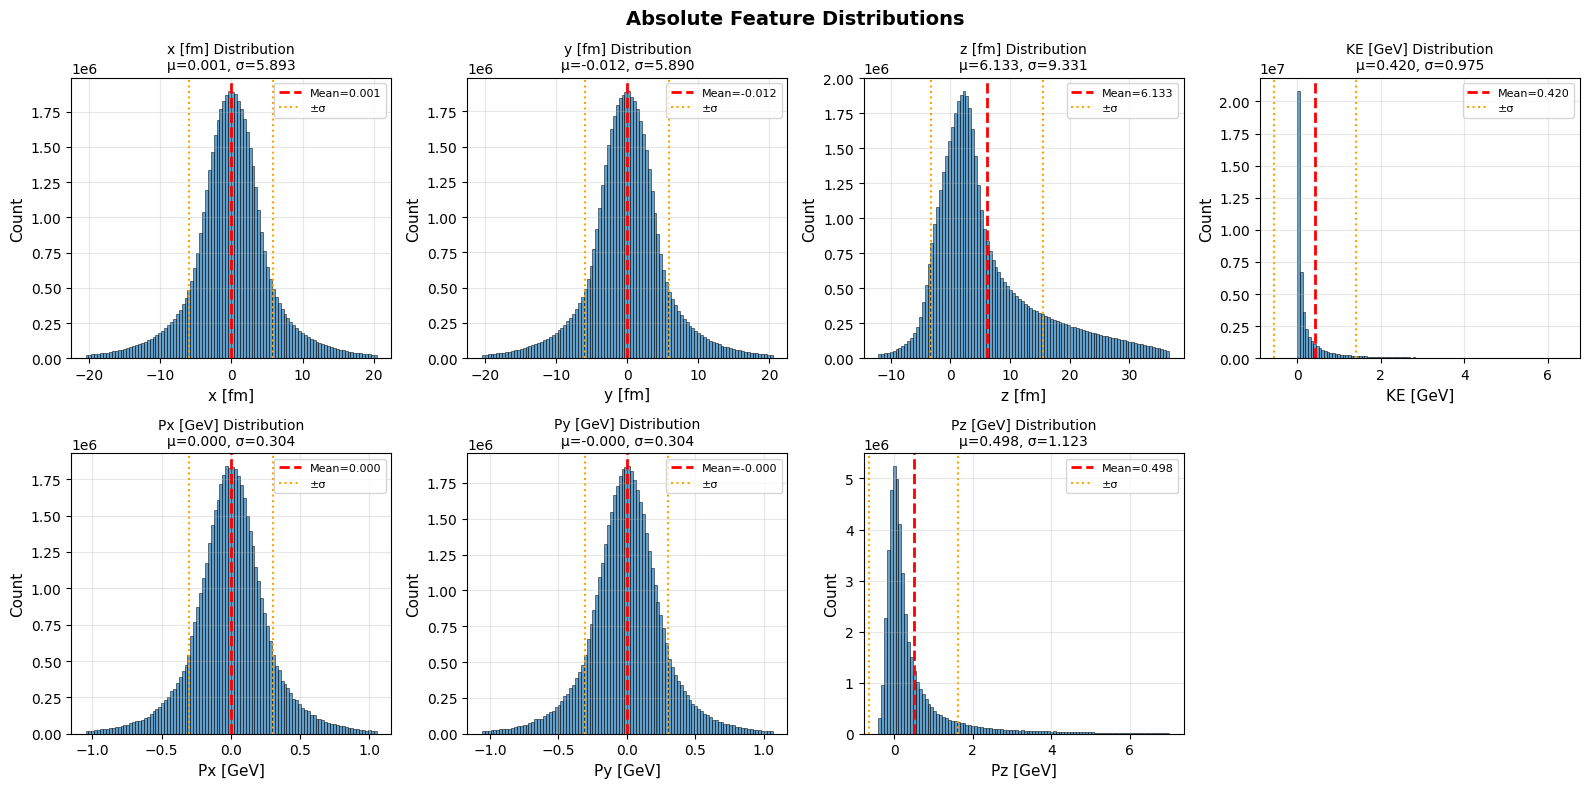

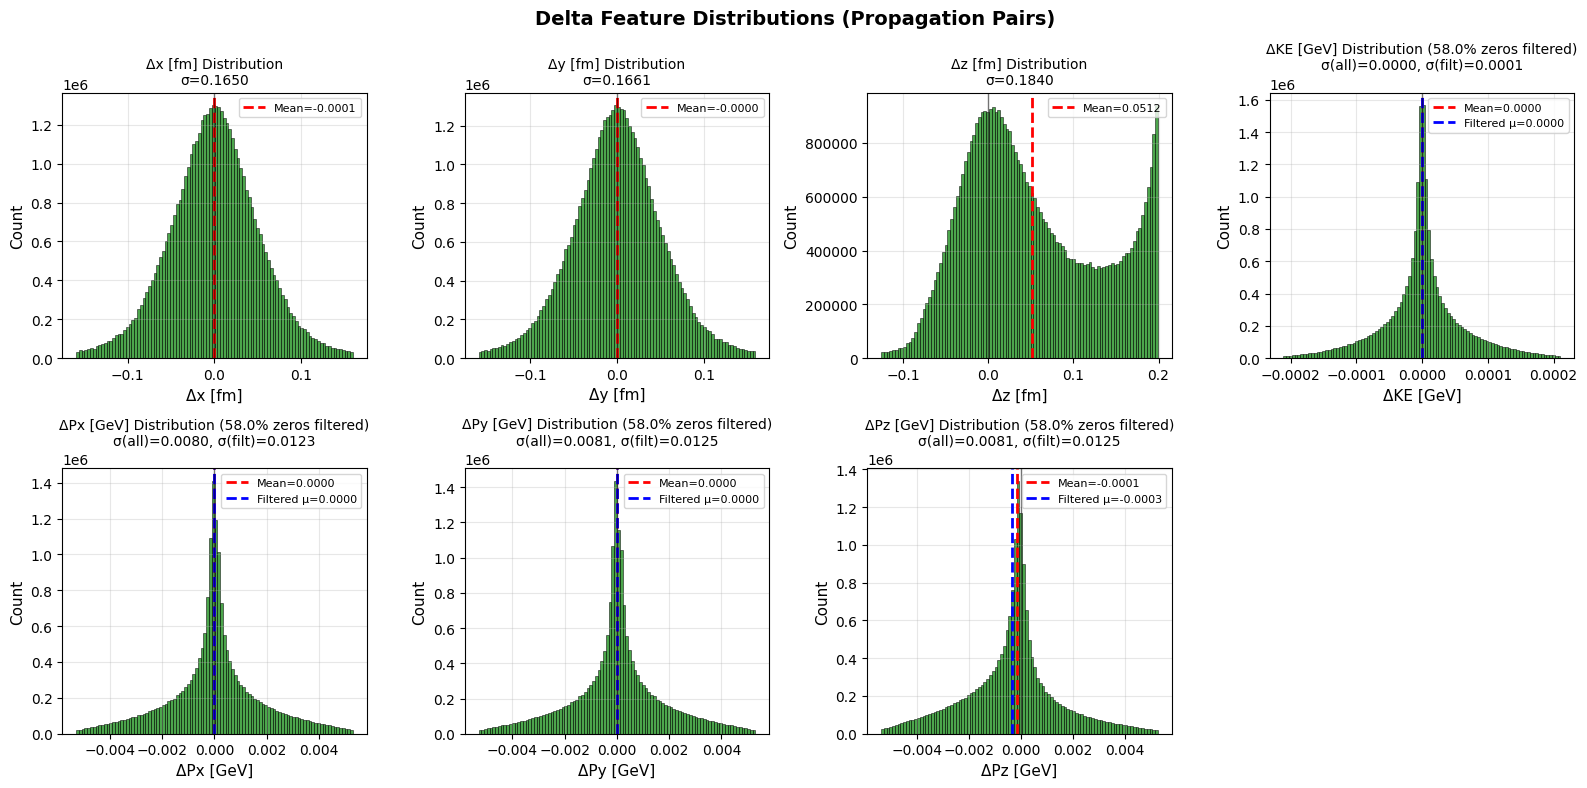


✓ Distribution plots complete!


In [16]:
import matplotlib.pyplot as plt

feature_names = ['x [fm]', 'y [fm]', 'z [fm]', 'KE [GeV]', 'Px [GeV]', 'Py [GeV]', 'Pz [GeV]']
delta_names = ['Δx [fm]', 'Δy [fm]', 'Δz [fm]', 'ΔKE [GeV]', 'ΔPx [GeV]', 'ΔPy [GeV]', 'ΔPz [GeV]']

# Percentile settings for outlier removal in plots
p_low_abs = 0.5   # Lower percentile for absolute features
p_upp_abs = 99.5  # Upper percentile for absolute features
p_low_delta = 0.5   # Lower percentile for delta features
p_upp_delta = 99.5  # Upper percentile for delta features

# Plot absolute features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    feat_values = all_features[:, i]
    
    # Use percentiles to handle outliers
    p_low, p_upp = np.percentile(feat_values, [p_low_abs, p_upp_abs])
    filtered = feat_values[(feat_values >= p_low) & (feat_values <= p_upp)]
    
    ax.hist(filtered, bins=100, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(FEATS_MEAN_COMPUTED[i], color='red', linestyle='--', linewidth=2, label=f'Mean={FEATS_MEAN_COMPUTED[i]:.3f}')
    ax.axvline(FEATS_MEAN_COMPUTED[i] + FEATS_SIGMA_COMPUTED[i], color='orange', linestyle=':', linewidth=1.5, label=f'±σ')
    ax.axvline(FEATS_MEAN_COMPUTED[i] - FEATS_SIGMA_COMPUTED[i], color='orange', linestyle=':', linewidth=1.5)
    ax.set_xlabel(feature_names[i], fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{feature_names[i]} Distribution\nμ={FEATS_MEAN_COMPUTED[i]:.3f}, σ={FEATS_SIGMA_COMPUTED[i]:.3f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[7].axis('off')
plt.suptitle('Absolute Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot delta features
if len(all_deltas) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Use tolerances from test cell (defined earlier)
    # Filter transitions where ALL FOUR E/P features are within tolerance
    
    for i in range(7):
        ax = axes[i]
        delta_values = all_deltas[:, i]
        
        # For E/P (indices 3,4,5,6): filter using the transition-level mask
        # For x,y,z (indices 0,1,2): use all values
        if i >= 3:
            # Use the same transition-level mask from statistics calculation
            delta_values_for_plot = delta_values[nonzero_transitions_mask]
            pct_zero = 100 * np.sum(all_ep_near_zero) / len(delta_values)
        else:
            delta_values_for_plot = delta_values
            pct_zero = 0
        
        # Use percentiles to handle outliers in the remaining data
        p_low, p_upp = np.percentile(delta_values_for_plot, [p_low_delta, p_upp_delta])
        filtered = delta_values_for_plot[(delta_values_for_plot >= p_low) & (delta_values_for_plot <= p_upp)]
        
        ax.hist(filtered, bins=100, alpha=0.7, edgecolor='black', linewidth=0.5, color='green')
        ax.axvline(FEATS_DELTA_MEAN_COMPUTED[i], color='red', linestyle='--', linewidth=2, label=f'Mean={FEATS_DELTA_MEAN_COMPUTED[i]:.4f}')
        if i >= 3:
            ax.axvline(FEATS_DELTA_MEAN_FILTERED[i], color='blue', linestyle='--', linewidth=2, label=f'Filtered μ={FEATS_DELTA_MEAN_FILTERED[i]:.4f}')
        ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax.set_xlabel(delta_names[i], fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        
        # Title with zero percentage for E/P features
        if i >= 3:
            title = f'{delta_names[i]} Distribution ({pct_zero:.1f}% zeros filtered)\nσ(all)={FEATS_DELTA_SIGMA_COMPUTED[i]:.4f}, σ(filt)={FEATS_DELTA_SIGMA_FILTERED[i]:.4f}'
        else:
            title = f'{delta_names[i]} Distribution\nσ={FEATS_DELTA_SIGMA_COMPUTED[i]:.4f}'
        
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[7].axis('off')
    plt.suptitle('Delta Feature Distributions (Propagation Pairs)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Distribution plots complete!")
else:
    print("\nNo delta distributions (no propagation pairs)")


---

## Training Integration

Examples for loading processed data in training notebooks.

**Next steps:**
- For **interaction model** (GiBUU_interaction.ipynb): Use `prepare_interaction_data()`
- For **propagation model** (GiBUU_propagation.ipynb): Use `prepare_propagation_data()`


In [17]:
# ============================================================================
# EXAMPLE 1: Prepare for INTERACTION model (GiBUU_interaction.ipynb)
# ============================================================================

# # Load NPZ and convert to pairs (flattened format)
# npz_files = glob.glob('./processed_data/npz_with_changes/*.npz')
# 
# pairs_loaded = []
# for npz_file in npz_files:
#     data = np.load(npz_file)
#     
#     # Reconstruct pairs from flattened format
#     input_lengths = data['input_lengths']
#     output_lengths = data['output_lengths']
#     input_particles = data['input_particles']
#     output_particles = data['output_particles']
#     
#     inp_offset = 0
#     out_offset = 0
#     for i in range(len(input_lengths)):
#         inp_len = input_lengths[i]
#         out_len = output_lengths[i]
#         
#         inp = input_particles[inp_offset:inp_offset+inp_len].tolist()
#         out = output_particles[out_offset:out_offset+out_len].tolist()
#         pairs_loaded.append((inp, out))
#         
#         inp_offset += inp_len
#         out_offset += out_len
# 
# # Prepare for transformer training
# from gibuu_transformer.data_processing import prepare_interaction_data
# 
# interaction_data = prepare_interaction_data(
#     pairs=pairs_loaded,
#     save_stats_path='feature_stats.json'
# )
# 
# print(f"✓ Prepared {len(interaction_data['input_encoded_ids'])} interaction sequences")


# ============================================================================
# EXAMPLE 2: Prepare for PROPAGATION model (GiBUU_propagation.ipynb)
# ============================================================================

# # Helper to load pairs from NPZ (flattened format)
# def load_pairs_from_npz(npz_files):
#     pairs = []
#     for npz_file in npz_files:
#         data = np.load(npz_file)
#         
#         # Reconstruct pairs from flattened format
#         input_lengths = data['input_lengths']
#         output_lengths = data['output_lengths']
#         input_particles = data['input_particles']
#         output_particles = data['output_particles']
#         
#         inp_offset = 0
#         out_offset = 0
#         for i in range(len(input_lengths)):
#             inp_len = input_lengths[i]
#             out_len = output_lengths[i]
#             
#             inp = input_particles[inp_offset:inp_offset+inp_len].tolist()
#             out = output_particles[out_offset:out_offset+out_len].tolist()
#             pairs.append((inp, out))
#             
#             inp_offset += inp_len
#             out_offset += out_len
#     return pairs
# 
# # Load both types
# with_changes_files = glob.glob('./processed_data/npz_with_changes/*.npz')
# without_changes_files = glob.glob('./processed_data/npz_without_changes/*.npz')
# 
# pairs_with_changes_loaded = load_pairs_from_npz(with_changes_files)
# pairs_without_changes_loaded = load_pairs_from_npz(without_changes_files)
# 
# # Prepare for propagation training
# from gibuu_transformer.data_processing import prepare_propagation_data
# 
# propagation_data = prepare_propagation_data(
#     pairs_without_changes=pairs_without_changes_loaded,
#     pairs_with_changes=pairs_with_changes_loaded,
#     stats_path='feature_stats.json'
# )
# 
# print(f"✓ Prepared {len(propagation_data['particle_types'])} propagation steps")

print("Uncomment examples above to use in training")


Uncomment examples above to use in training
